# Preparing the dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/real_estate_data.csv')

In [3]:
df.head()

,Unnamed: 0,Seller Name,Seller type,BHK,Location,City,Total Price,price per sqft,Area_sqft,Construction status
0,0,Eco Green Builders,BUILDER,3 BHK Apartment,Gundlapochampally,Hyderabad,65.98 L,"4,200",1571,Under Construction
1,1,Elemental Realty,BUILDER,4 BHK Villa,Patancheru,Hyderabad,1.48 Cr,"7,700",1930,Under Construction
2,2,Riddhi Group,BUILDER,4 BHK Villa,Tukkuguda,Hyderabad,2.99 Cr,"7,200",4157,Under Construction
3,3,APR Group,BUILDER,4 BHK Villa,Bachupally,Hyderabad,4.08 Cr,"12,000",3400,Under Construction
4,4,Grenstone Infra,BUILDER,4 BHK Villa,Maheshwaram,Hyderabad,1.4 Cr,"5,200",2701,Under Construction


In [4]:
df.shape

(9960, 10)

# Data Preprocessing

## Checking for missing values

In [5]:
df.isna().sum()

Unnamed: 0             0
Seller Name            0
Seller type            0
BHK                    0
Location               0
City                   0
Total Price            0
price per sqft         0
Area_sqft              0
Construction status    0
dtype: int64

## Remove unwanted columns and rename

In [6]:
df = df.drop('Unnamed: 0', axis=1)

In [7]:
df.insert(0, 'seller_name', df['Seller Name'].apply(lambda x: x.strip()))
df = df.drop('Seller Name', axis=1)

In [8]:
df.insert(1, 'seller_type', df['Seller type'].apply(lambda x: x.strip()))
df = df.drop('Seller type', axis=1)

In [9]:
df.insert(2, 'bhk', df['BHK'].apply(lambda x: x.strip()))
df = df.drop('BHK', axis=1)

In [10]:
df.insert(3, 'location', df['Location'].apply(lambda x: x.strip()))
df = df.drop('Location', axis=1)

In [11]:
df.insert(4, 'city', df['City'].apply(lambda x: x.strip()))
df = df.drop('City', axis=1)

In [12]:
df.insert(5, 'price_per_sqft', df['price per sqft'].apply(lambda x: x.strip()))
df = df.drop('price per sqft', axis=1)

In [13]:
df.insert(6, 'area', df['Area_sqft'])
df = df.drop('Area_sqft', axis=1)

In [14]:
df.insert(7, 'construction_status', df['Construction status'].apply(lambda x: x.strip()))
df = df.drop('Construction status', axis=1)

In [15]:
df.insert(8, 'price', df['Total Price'].apply(lambda x: x.strip()))
df = df.drop('Total Price', axis=1)

In [16]:
df.head()

,seller_name,seller_type,bhk,location,city,price_per_sqft,area,construction_status,price
0,Eco Green Builders,BUILDER,3 BHK Apartment,Gundlapochampally,Hyderabad,"4,200",1571,Under Construction,65.98 L
1,Elemental Realty,BUILDER,4 BHK Villa,Patancheru,Hyderabad,"7,700",1930,Under Construction,1.48 Cr
2,Riddhi Group,BUILDER,4 BHK Villa,Tukkuguda,Hyderabad,"7,200",4157,Under Construction,2.99 Cr
3,APR Group,BUILDER,4 BHK Villa,Bachupally,Hyderabad,"12,000",3400,Under Construction,4.08 Cr
4,Grenstone Infra,BUILDER,4 BHK Villa,Maheshwaram,Hyderabad,"5,200",2701,Under Construction,1.4 Cr


## Getting value counts of categorical variables

In [17]:
df['seller_name'].value_counts()

seller                           1137
Dial To Property                  293
PropertyPistol Realty Pvt Ltd     261
Prop Search                       226
JP Associates                     188
                                 ... 
Ravi teja                           1
Vamsi Kishan                        1
VibrantKey                          1
bhattrealcon                        1
Shri Krishna Properties             1
Name: seller_name, Length: 425, dtype: int64

In [18]:
df['seller_type'].value_counts()

AGENT             7952
VERIFIED OWNER    1137
BUILDER            871
Name: seller_type, dtype: int64

In [19]:
df['bhk'].value_counts()

2 BHK Apartment             2914
3 BHK Apartment             1973
1 BHK Apartment             1862
Residential Plot            1810
4 BHK Apartment              380
4 BHK Villa                  193
1 RK Studio Apartment        139
3 BHK Villa                  138
4 BHK Independent House       98
5 BHK Apartment               89
2 BHK Independent House       74
3 BHK Independent House       41
5 BHK Independent House       36
5 BHK Villa                   30
5 BHK Independent Floor       27
3 BHK Independent Floor       18
6 BHK Independent House       18
6 BHK Apartment               14
7 BHK Independent House       11
10 BHK Independent House      11
1 BHK Independent House        9
2 BHK Independent Floor        9
4 BHK Independent Floor        8
8 BHK Independent House        7
9 BHK Independent House        6
8 BHK Apartment                6
2 BHK Villa                    6
7 BHK Apartment                5
2 RK Studio Apartment          4
9 BHK Apartment                4
6 BHK Vill

In [20]:
df['location'].value_counts()

Mira Road East    982
Thane West        494
Dombivali         275
Kalyan West       251
Yacharam          167
                 ... 
Ganga Nagar         1
Kavadipally         1
Appa Junction       1
Osman Nagar         1
Juinagar West       1
Name: location, Length: 437, dtype: int64

In [21]:
df['city'].value_counts()

Hyderabad    4980
Mumbai       4980
Name: city, dtype: int64

In [22]:
df['construction_status'].value_counts()

Ready to move         4797
Under Construction    3353
New                   1568
Resale                 242
Name: construction_status, dtype: int64

## Column creation

### Extracting Plot type from BHK

In [23]:
def get_plot_type(text: str) -> str:
  text = text.strip()
  if 'BHK' in text:
    return text.split('BHK')[1].strip()

  if 'RK' in text:
    return text.split('RK')[1].strip()

  return text.strip()

In [24]:
df.insert(3, 'plot_type', df['bhk'].apply(get_plot_type))

In [25]:
def get_bhk(text: str) -> str:
  result = text.strip().replace(get_plot_type(text), '')
  if result == '':
    return 0
  
  return int(result.split()[0])

In [26]:
df.insert(4, 'bhk/rk', df['bhk'].apply(get_bhk))
df = df.drop(['bhk'], axis=1)

In [27]:
df.head()

,seller_name,seller_type,plot_type,bhk/rk,location,city,price_per_sqft,area,construction_status,price
0,Eco Green Builders,BUILDER,Apartment,3,Gundlapochampally,Hyderabad,"4,200",1571,Under Construction,65.98 L
1,Elemental Realty,BUILDER,Villa,4,Patancheru,Hyderabad,"7,700",1930,Under Construction,1.48 Cr
2,Riddhi Group,BUILDER,Villa,4,Tukkuguda,Hyderabad,"7,200",4157,Under Construction,2.99 Cr
3,APR Group,BUILDER,Villa,4,Bachupally,Hyderabad,"12,000",3400,Under Construction,4.08 Cr
4,Grenstone Infra,BUILDER,Villa,4,Maheshwaram,Hyderabad,"5,200",2701,Under Construction,1.4 Cr


## Feature encoding

### Defining functions

In [28]:
def encode(column, encodings):
    encoded_column = column.map(encodings)
    return encoded_column

In [29]:
def create_encodings(column, price):
    df_temp = pd.DataFrame({'column': column, 'price': price})
    unique_categories = df_temp['column'].unique()
    avg_prices = df_temp.groupby('column')['price'].mean()
    sorted_categories = list(sorted(unique_categories, key=lambda x: avg_prices[x]))
    encodings = {category: index for index, category in enumerate(sorted_categories)}
    return encodings

### Encoding the categorical variables

In [30]:
encodings = {}

In [31]:
encoding_variables = ['seller_name', 'seller_type', 'plot_type', 'location', 'city', 'construction_status']

In [32]:
def price_to_lacs(text: str) -> float:
  text = text.strip()
  if 'L' in text:
    return int(float(text.split()[0]))

  return int(float(text.split()[0]) * 100)

In [33]:
for column in encoding_variables:
  encodings[column] = create_encodings(df[column], df['price'].apply(price_to_lacs))

### Creating a numeric dataframe

In [34]:
df_num = pd.DataFrame()

In [35]:
for column in encoding_variables:
  df_num[column] = encode(df[column], encodings[column])

In [36]:
df_num.insert(3, 'bhk/rk', df['bhk/rk'])

In [37]:
df_num.insert(6, 'area', df['area'])

### Converting prices to lacs

In [38]:
df_num['price'] = df['price'].apply(price_to_lacs)

In [39]:
df_num.head()

,seller_name,seller_type,plot_type,bhk/rk,location,city,area,construction_status,price
0,144,1,3,3,191,0,1571,2,65
1,326,1,5,4,252,0,1930,2,148
2,300,1,5,4,265,0,4157,2,299
3,387,1,5,4,298,0,3400,2,408
4,311,1,5,4,120,0,2701,2,140


## Checking for inconsistencies

In [40]:
(df_num < 0).sum().sum()

0

## Removing outliers

In [41]:
value_counts = df_num['price'].value_counts().to_dict()

In [42]:
df_fil = df_num[df_num['price'].apply(lambda x: value_counts[x] > 10)]

# Exploratory Data Analysis

In [43]:
import seaborn as sns

<Axes: >

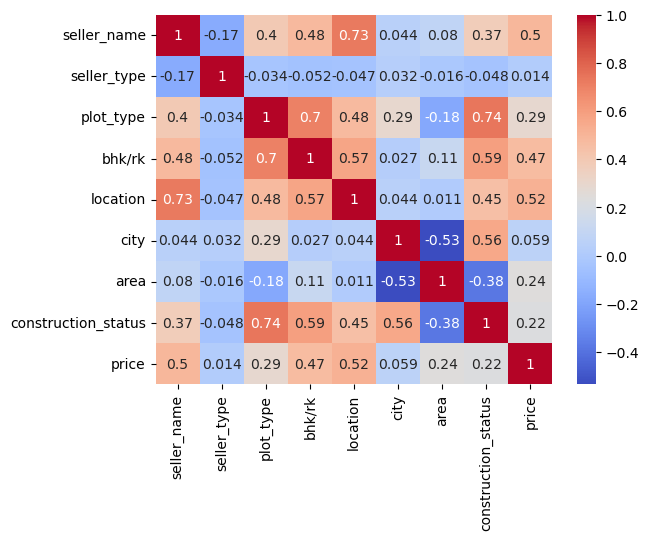

In [44]:
sns.heatmap(df_fil.corr(), annot=True, fmt='.2g',cmap='coolwarm')

# Model Training

## Dividing into X and Y

In [45]:
X = df_fil.iloc[:, 2:-1]

In [46]:
X.head()

,plot_type,bhk/rk,location,city,area,construction_status
0,3,3,191,0,1571,2
1,5,4,252,0,1930,2
4,5,4,120,0,2701,2
7,1,0,78,0,3150,0
8,3,2,234,0,1310,2


In [47]:
Y = df_fil.iloc[:, -1]

In [48]:
Y.head()

0     65
1    148
4    140
7     63
8     73
Name: price, dtype: int64

In [49]:
stats = lambda x: {'Max': max(x), 'Min': min(x), 'Range': sum(x) / len(x)}

In [50]:
stats(Y)

{'Max': 2000, 'Min': 10, 'Range': 88.09070191431177}

## Dividing into train and test

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [53]:
X_train.head(), X_test.head()

(      plot_type  bhk/rk  location  city  area  construction_status
 7564          3       1       187     1   655                    3
 5881          3       3       359     1  1116                    2
 4711          4       2       200     0  1080                    3
 5382          3       3       131     1  1115                    3
 321           3       3       260     0  1665                    2,
       plot_type  bhk/rk  location  city  area  construction_status
 3313          1       0        90     0  2250                    0
 3018          1       0       120     0  1800                    0
 9281          3       2       221     1   910                    3
 3619          1       0       183     0  1080                    1
 4959          3       2       186     0  1100                    3)

In [54]:
Y_train.head(), Y_test.head()

(7564     43
 5881    285
 4711     65
 5382     66
 321      91
 Name: price, dtype: int64,
 3313    25
 3018    38
 9281    85
 3619    36
 4959    58
 Name: price, dtype: int64)

## Training a model on the data

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

# Model Evaluation

## Plotting residuals

In [57]:
import matplotlib.pyplot as plt

In [58]:
Y_pred = model.predict(X_test)
residuals = Y_pred - Y_test

In [59]:
stats(abs(residuals))

{'Max': 1742.1749846970329,
 'Min': 0.0016478847505396743,
 'Range': 31.864534035534966}

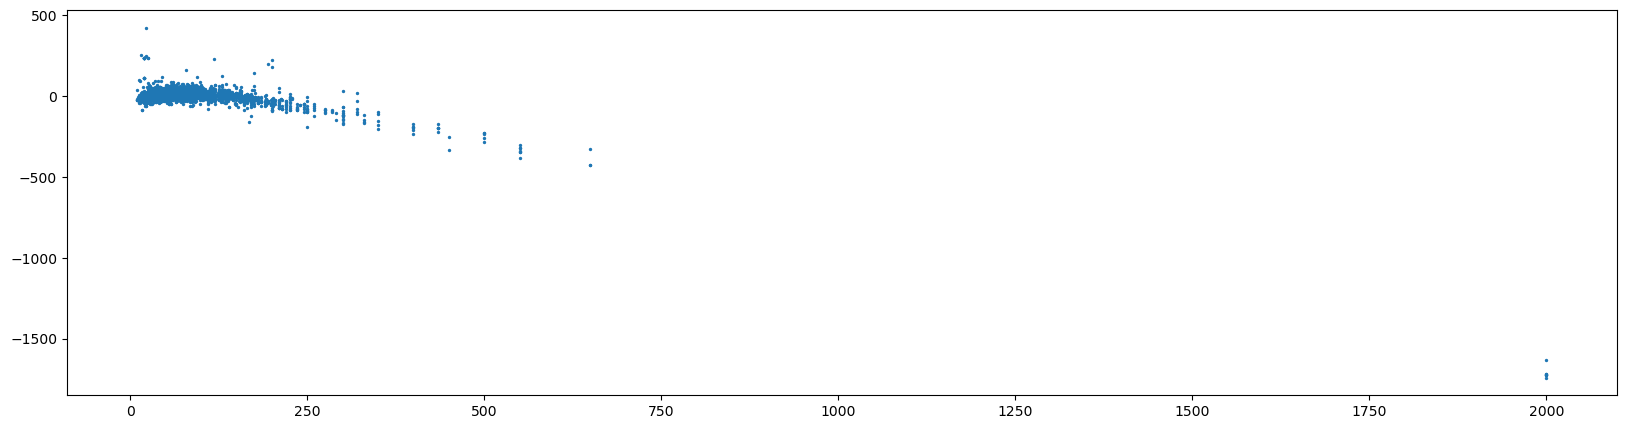

In [60]:
plt.figure(figsize=(20, 5))
plt.scatter(Y_test, residuals, s=2)

## Getting k-fold scores

In [61]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import get_scorer_names

In [62]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, Y, cv=kfold, scoring='neg_mean_absolute_error')

In [63]:
scores.mean(), scores.std()

(-30.05981712151305, 2.069831477607236)

## Getting the coefficients and intercept

In [71]:
model.coef_.tolist(), model.intercept_

([-1.155697597912672,
  25.085097074546553,
  0.3762742273707314,
  54.14879832433557,
  0.025523288905412854,
  -17.634604124305273],
 -58.009653591402255)

# Saving the model

In [65]:
import json
import pickle as pk

In [66]:
json.dump({'encoding_variables': encoding_variables, 
           'encodings': encodings, 
           'df_dict': df.to_dict(), 
           'columns': X.columns.tolist()}, open('../cache/input_cache.json', 'w'))

In [67]:
pk.dump(model, open('../models/linear_regression.sav', 'wb'))